In [147]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [148]:
df= pd.read_csv("./datasets/regularization.csv")

In [149]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,y
0,0.4967,0.4259,0.4828,-0.8290,-0.9087,0.9262,0.9008,3.8397
1,-0.1383,-0.1593,-0.0684,-0.5602,-0.5901,1.9094,1.4847,6.7519
2,0.6477,0.6306,0.6912,0.7473,0.7476,-1.3986,-1.0583,-3.5807
3,1.5230,1.4829,1.4761,0.6104,0.6127,0.5630,0.6819,1.5410
4,-0.2342,-0.2422,-0.3485,-0.0209,-0.0434,-0.6506,-0.4910,-5.8384


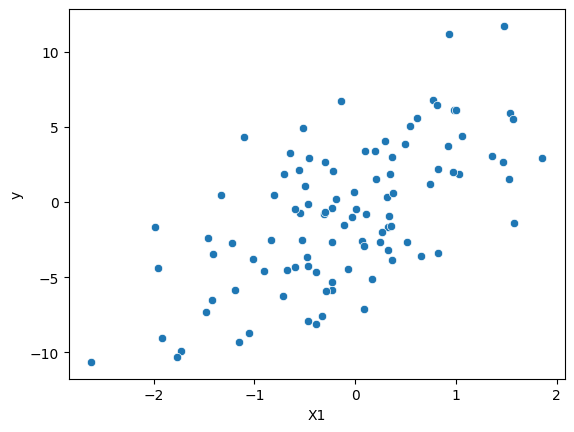

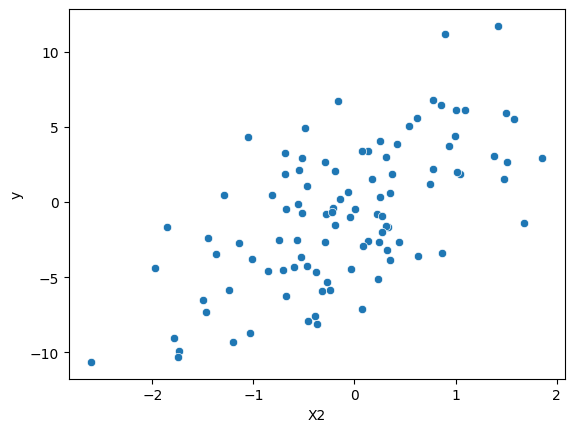

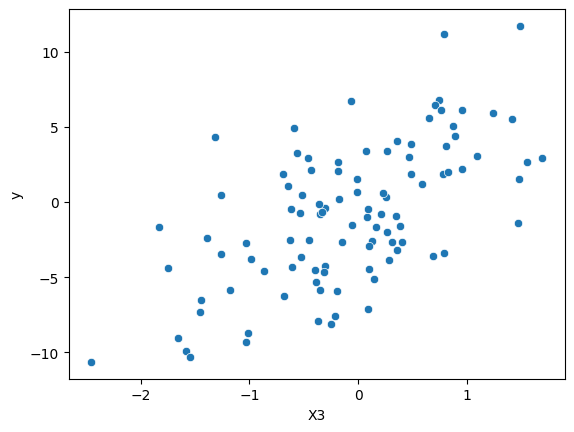

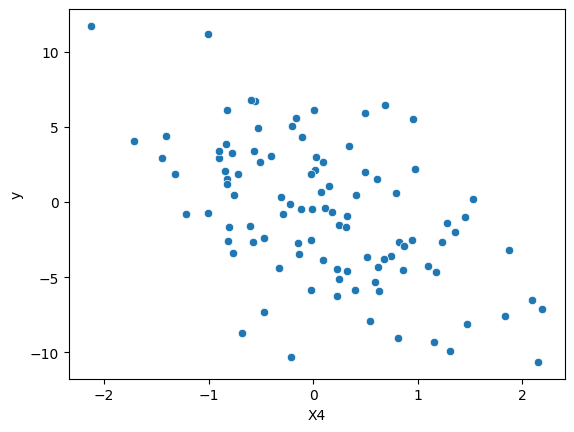

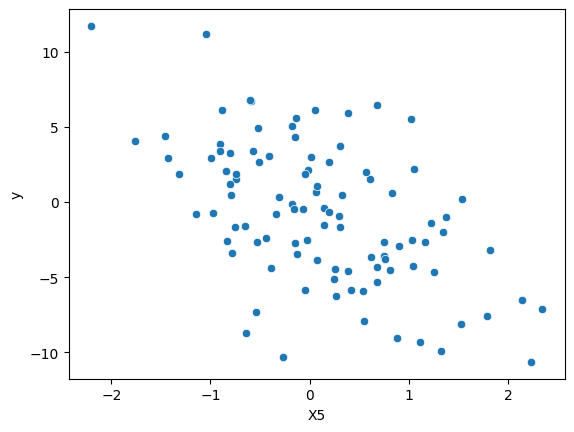

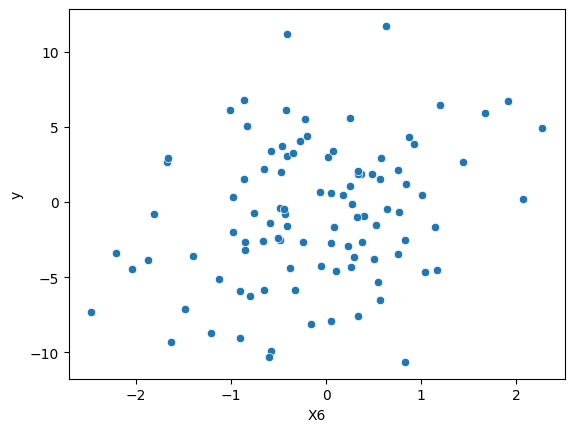

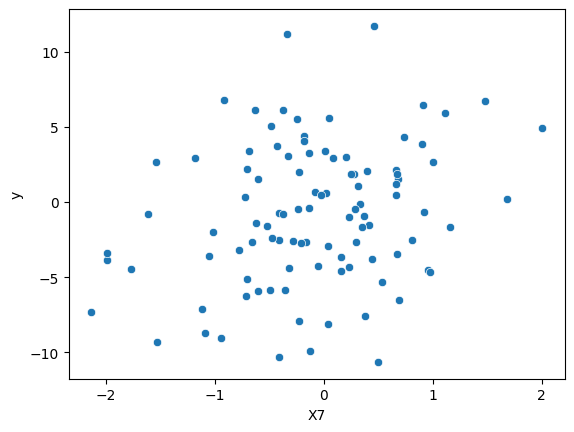

In [150]:
for cols in df.columns[:-1]:
    sns.scatterplot(x= df[cols], y=df['y'])
    plt.show()

In [151]:
df.cov()

,X1,X2,X3,X4,X5,X6,X7,y
X1,0.824756,0.818853,0.761078,-0.136673,-0.143252,-0.127889,-0.103048,2.671749
X2,0.818853,0.815223,0.755575,-0.137417,-0.143512,-0.133603,-0.107264,2.653491
X3,0.761078,0.755575,0.713644,-0.123031,-0.129564,-0.130320,-0.107648,2.437953
X4,-0.136673,-0.137417,-0.123031,0.781635,0.791711,0.059261,0.056111,-2.196156
X5,-0.143252,-0.143512,-0.129564,0.791711,0.804615,0.054892,0.053372,-2.250417
X6,-0.127889,-0.133603,-0.130320,0.059261,0.054892,0.852922,0.712655,1.175982
X7,-0.103048,-0.107264,-0.107648,0.056111,0.053372,0.712655,0.620904,0.943345
y,2.671749,2.653491,2.437953,-2.196156,-2.250417,1.175982,0.943345,21.834549


In [152]:
df.corr()

,X1,X2,X3,X4,X5,X6,X7,y
X1,1.000000,0.998630,0.992032,-0.170223,-0.175850,-0.152481,-0.144001,0.629594
X2,0.998630,1.000000,0.990601,-0.172147,-0.177197,-0.160223,-0.150767,0.628937
X3,0.992032,0.990601,1.000000,-0.164729,-0.170982,-0.167037,-0.161716,0.617607
X4,-0.170223,-0.172147,-0.164729,1.000000,0.998322,0.072580,0.080544,-0.531605
X5,-0.175850,-0.177197,-0.170982,0.998322,1.000000,0.066262,0.075511,-0.536904
X6,-0.152481,-0.160223,-0.167037,0.072580,0.066262,1.000000,0.979293,0.272505
X7,-0.144001,-0.150767,-0.161716,0.080544,0.075511,0.979293,1.000000,0.256204
y,0.629594,0.628937,0.617607,-0.531605,-0.536904,0.272505,0.256204,1.000000


<Axes: >

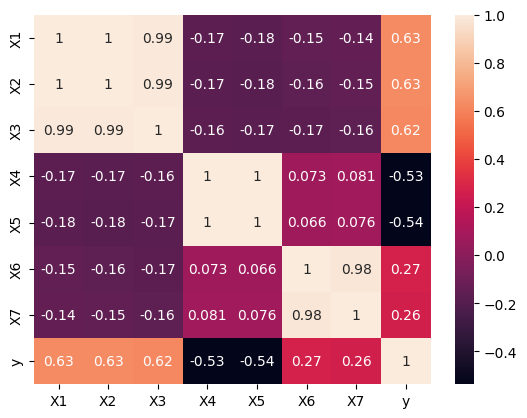

In [153]:
sns.heatmap(df.corr(), annot= True)

In [154]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(df.drop(columns= "y"), df['y'], random_state= 42, train_size= 0.8)

In [155]:
# normal regression
from sklearn.linear_model import LinearRegression

lr= LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [156]:
y_pred= lr.predict(x_test)
y_pred

array([ 4.26173808,  2.80217536,  0.53895104, -3.87872921, -7.36821141,
        0.4875642 ,  1.46620602,  2.30962412, -1.37177565,  4.88505402,
       -2.996465  , -0.78687556,  2.02526973, -3.53312336,  2.57190028,
       -1.67538987, -1.38098582,  0.62650281, -1.50812426,  5.04611365])

In [157]:
from sklearn.metrics import r2_score, mean_squared_error

print(r2_score(y_true= y_test, y_pred= y_pred))
print(np.sqrt(mean_squared_error(y_true= y_test, y_pred= y_pred)))

0.6997062742321494
2.418168351466677


In [158]:
lr.coef_

array([-4.62544994,  8.65147184, -1.09078112,  0.88102262, -3.33786754,
        2.36087836, -0.59709164])

In [159]:
lr.intercept_

np.float64(0.07294440278948966)

In [160]:
# Applying rigged regression

from sklearn.linear_model import Ridge

ridge= Ridge(alpha= 10)  #10 is optimal for this dataset

ridge.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [161]:
y_pred= ridge.predict(x_test)
y_pred

array([ 3.573571  ,  2.48489522,  1.20078866, -3.940264  , -7.16254154,
        0.81447184,  1.37959273,  2.08617548, -0.35866733,  5.04994633,
       -3.13795044, -0.81899734,  1.65152097, -3.47341693,  2.46918557,
       -1.72500589, -1.55801553,  0.21731799, -1.47586963,  4.87171193])

In [ ]:
print(r2_score(y_true= y_test, y_pred= y_pred))
print(np.sqrt(mean_squared_error(y_true= y_test, y_pred= y_pred)))

0.7069204645101819
2.3889449989043867


In [163]:
ridge.coef_

array([ 1.00828531,  1.11653052,  0.75696912, -1.16159862, -1.22076108,
        1.10183344,  0.66848013])

In [164]:
ridge.intercept_

np.float64(0.013180097748809572)

In [165]:
# applying ridge regression using GD
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

Scaler= StandardScaler()

x_train_scaled= Scaler.fit_transform(x_train)
x_test_scaled= Scaler.transform(x_test)


In [166]:
sgd = SGDRegressor(
    penalty='l2',          # correct — this IS ridge
    alpha=0.01,            # much lower: try 0.0001 to 0.1 range
    max_iter=1000,         # give it more iterations to converge
    eta0=0.01,  
    learning_rate= "constant"  ,         # 10x higher — moves meaningfully each step
    #learning_rate='invscaling',  # better than constant: decays over time
    #tol=1e-4,              # stop early when loss stops improving
    random_state=42
)

sgd.fit(x_train_scaled, y_train)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.01
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [167]:
y_pred= sgd.predict(x_test_scaled)
y_pred

array([ 4.46032365,  2.88069332,  1.4529372 , -4.30939112, -7.99037451,
        0.97531225,  1.66039161,  2.57421986, -0.18459667,  5.88722738,
       -3.29410691, -0.67665728,  1.76999789, -3.75748069,  2.93756391,
       -1.834352  , -1.64730105,  0.50070453, -1.60588366,  5.30429135])

In [168]:
print(r2_score(y_true= y_test, y_pred= y_pred))
print(np.sqrt(mean_squared_error(y_true= y_test, y_pred= y_pred)))

0.7207175261733032
2.3320359715634926


In [169]:
sgd.coef_

array([ 0.97730429,  1.18043487,  0.69263933, -1.24537728, -1.28238914,
        1.15582874,  0.62721313])

In [170]:
sgd.intercept_

array([-0.90435016])

There are a few ways to find the best alpha systematically rather than guessing.
RidgeCV is just Ridge + Cross Validation built-in — it automatically finds the best alpha for you in one step.

In [177]:
from sklearn.linear_model import RidgeCV  #ridge cv performs ridge regression with the best alpha value from the given list of alpha value

# automatically tries all these alphas and picks the best one
ridge_cv = RidgeCV(
    alphas=[0.001, 0.01, 0.1, 1, 10, 100],
    cv=5    # 5-fold cross validation
)
ridge_cv.fit(x_train_scaled, y_train)

print(ridge_cv.alpha_)  # ← best alpha found

10.0


In [178]:
y_pred= ridge_cv.predict(x_test_scaled)

In [179]:
print(r2_score(y_true= y_test, y_pred= y_pred))
print(np.sqrt(mean_squared_error(y_true= y_test, y_pred= y_pred)))



0.7104544506683779
2.3744982322584267
